# ML Core Concepts & scikit-learn

## Learning Objectives
- Master train/validation/test split and data partitioning
- Understand overfitting, underfitting, and the bias-variance tradeoff
- Apply cross-validation techniques for robust model evaluation
- Learn and apply KNN (K-Nearest Neighbors) algorithm
- Learn and apply SVM (Support Vector Machine) algorithm
- Compare and select appropriate models for different problems

---

## Part 1: Dataset Preparation & Train/Val/Test Split

In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
  Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl.metadata (60 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 1.5 MB/s eta 0:00:06
   --- ------------------------------------ 0.8/8.1 MB 1.5 MB/s eta 0:00:06
   ----- ---------------------------------- 1.0/8.1 MB 1.5 MB/s eta 0:00:05
   ------ --------------------------------- 1.3/8.1 MB 1.5 MB/s eta 0:00:05
   ------- -------------------------------- 1.6/8.1 MB 1.5 MB/s eta 0:00:05
   ---------- ----------------------------- 2.1/8.1 MB 1.6 MB/s eta 0:00:04
   ----------- ---------------------------- 2.4/8.1 MB 1.6 MB/s eta 0:00:04
   ------------ --------------------------- 2.6/8.1 MB 1.6 MB/s eta 0:00:04
   --------------- -----------------


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
from sklearn.datasets import make_classification, make_regression, load_iris, load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import SVC, SVR
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, mean_squared_error, r2_score)
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries loaded successfully!")
print("scikit-learn version:", __import__('sklearn').__version__)

Libraries loaded successfully!
scikit-learn version: 1.8.0


### 1.1 Train/Validation/Test Split

**Purpose:**
- **Training Set**: Used to train the model (60-70% of data)
- **Validation Set**: Used to tune hyperparameters and evaluate during training (15-20% of data)
- **Test Set**: Final evaluation on unseen data (15-20% of data)

**Why separate?** To prevent data leakage and get unbiased estimates of model performance.

In [3]:
# Create a classification dataset
X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, 
                           n_redundant=5, random_state=42)

print("Dataset shape:", X.shape)
print("Class distribution:", np.bincount(y))

# Step 1: Split into train+val (80%) and test (20%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: Split train+val into train (75% of 80% = 60%) and val (25% of 80% = 20%)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print("\n--- Data Split Sizes ---")
print(f"Training set:   {X_train.shape[0]} samples ({100*X_train.shape[0]/len(X):.1f}%)")
print(f"Validation set: {X_val.shape[0]} samples ({100*X_val.shape[0]/len(X):.1f}%)")
print(f"Test set:       {X_test.shape[0]} samples ({100*X_test.shape[0]/len(X):.1f}%)")

# Verify class distribution is preserved
print("\nClass distribution preserved:")
print(f"Train: {np.bincount(y_train)}")
print(f"Val:   {np.bincount(y_val)}")
print(f"Test:  {np.bincount(y_test)}")

Dataset shape: (1000, 20)
Class distribution: [502 498]

--- Data Split Sizes ---
Training set:   600 samples (60.0%)
Validation set: 200 samples (20.0%)
Test set:       200 samples (20.0%)

Class distribution preserved:
Train: [297 303]
Val:   [ 99 101]
Test:  [106  94]


---

## Part 2: Overfitting, Underfitting & Bias-Variance Tradeoff

### 2.1 Understanding Overfitting and Underfitting

- **Underfitting**: Model is too simple, high training and test error
- **Good Fit**: Balance between bias and variance, low test error
- **Overfitting**: Model is too complex, low training error but high test error

K= 1 | Train Acc: 1.0000 | Val Acc: 0.9150
K= 3 | Train Acc: 0.9700 | Val Acc: 0.8950
K= 5 | Train Acc: 0.9633 | Val Acc: 0.9100
K=10 | Train Acc: 0.9267 | Val Acc: 0.9150
K=20 | Train Acc: 0.9017 | Val Acc: 0.8700
K=50 | Train Acc: 0.8700 | Val Acc: 0.8650


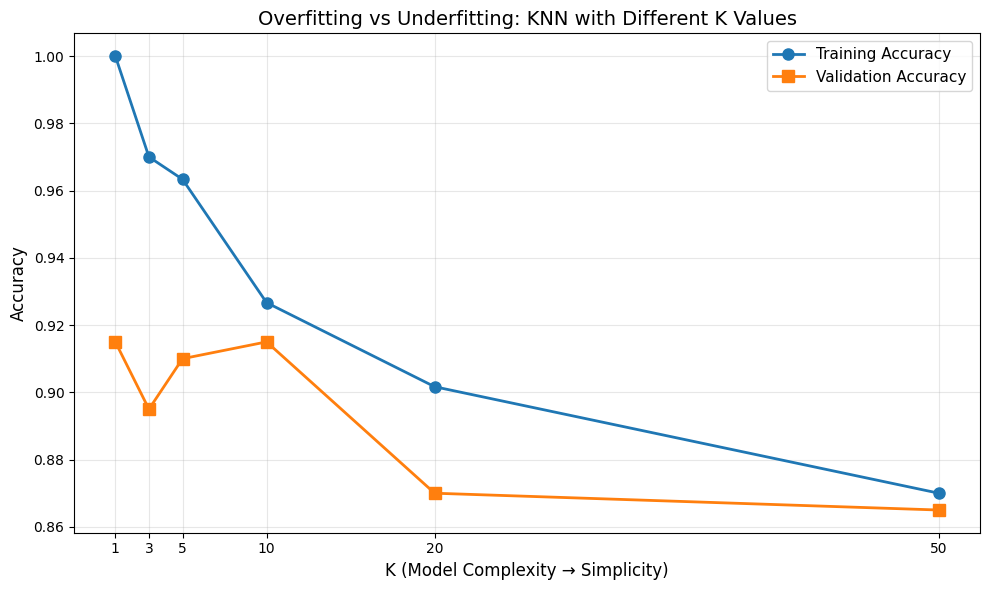


--- Interpretation ---
Low K (1, 3, 5):   OVERFITTING → High train, low validation
Medium K (10, 20): GOOD FIT     → Both train and validation are high
High K (50):       UNDERFITTING → Both are lower


In [4]:
# Demonstrate overfitting with KNN using different K values
# K = 1 (complex) to K = 50 (simple)

k_values = [1, 3, 5, 10, 20, 50]
train_scores = []
val_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    train_score = knn.score(X_train, y_train)
    val_score = knn.score(X_val, y_val)
    
    train_scores.append(train_score)
    val_scores.append(val_score)
    
    print(f"K={k:2d} | Train Acc: {train_score:.4f} | Val Acc: {val_score:.4f}")

# Visualize the bias-variance tradeoff
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_scores, 'o-', linewidth=2, markersize=8, label='Training Accuracy')
plt.plot(k_values, val_scores, 's-', linewidth=2, markersize=8, label='Validation Accuracy')
plt.xlabel('K (Model Complexity → Simplicity)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Overfitting vs Underfitting: KNN with Different K Values', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(k_values)
plt.tight_layout()
plt.show()

# Annotate regions
print("\n--- Interpretation ---")
print("Low K (1, 3, 5):   OVERFITTING → High train, low validation")
print("Medium K (10, 20): GOOD FIT     → Both train and validation are high")
print("High K (50):       UNDERFITTING → Both are lower")

### 2.2 Bias-Variance Decomposition

**Error = Bias² + Variance + Irreducible Error**

- **Bias**: How much predictions deviate from true values on average (underfitting)
- **Variance**: Sensitivity to training data variations (overfitting)
- **Goal**: Find the sweet spot that minimizes both bias and variance

K  | Bias    | Variance | Total Error
------------------------------------------
 1 | 0.0744 | 0.0589   | 0.1333
 3 | 0.0695 | 0.0513   | 0.1208
 5 | 0.0692 | 0.0575   | 0.1268
10 | 0.0803 | 0.0567   | 0.1370
20 | 0.0954 | 0.0566   | 0.1520
50 | 0.1657 | 0.0621   | 0.2278


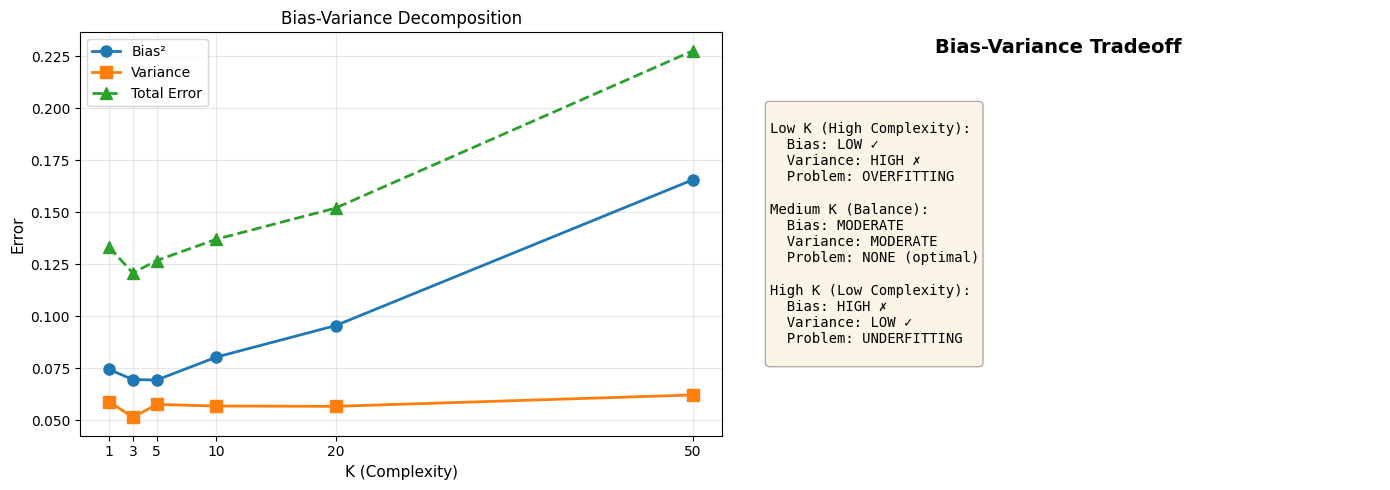

In [5]:
# Estimate bias and variance with multiple random training sets
def estimate_bias_variance(X_train, y_train, X_val, y_val, k, n_iterations=20):
    """
    Estimate bias and variance by training multiple models on 
    different random subsets of training data.
    """
    predictions = []
    
    for i in range(n_iterations):
        # Random subset of training data
        indices = np.random.choice(len(X_train), size=len(X_train)//2, replace=False)
        X_subset = X_train[indices]
        y_subset = y_train[indices]
        
        # Train and predict
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_subset, y_subset)
        preds = knn.predict(X_val).reshape(-1, 1)
        predictions.append(preds)
    
    predictions = np.hstack(predictions)
    
    # Bias: average prediction vs true value
    avg_pred = predictions.mean(axis=1)
    bias = np.mean((avg_pred - y_val)**2)
    
    # Variance: spread of predictions for same samples
    variance = np.mean(np.var(predictions, axis=1))
    
    return bias, variance

# Calculate for different K values
k_values = [1, 3, 5, 10, 20, 50]
biases = []
variances = []

print("K  | Bias    | Variance | Total Error")
print("-" * 42)

for k in k_values:
    bias, variance = estimate_bias_variance(X_train, y_train, X_val, y_val, k)
    biases.append(bias)
    variances.append(variance)
    total = bias + variance
    print(f"{k:2d} | {bias:.4f} | {variance:.4f}   | {total:.4f}")

# Visualize bias-variance tradeoff
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Bias and Variance
axes[0].plot(k_values, biases, 'o-', linewidth=2, markersize=8, label='Bias²')
axes[0].plot(k_values, variances, 's-', linewidth=2, markersize=8, label='Variance')
axes[0].plot(k_values, np.array(biases) + np.array(variances), '^--', 
             linewidth=2, markersize=8, label='Total Error')
axes[0].set_xlabel('K (Complexity)', fontsize=11)
axes[0].set_ylabel('Error', fontsize=11)
axes[0].set_title('Bias-Variance Decomposition', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(k_values)

# Plot 2: Conceptual diagram
axes[1].axis('off')
axes[1].text(0.5, 0.95, 'Bias-Variance Tradeoff', ha='center', fontsize=14, weight='bold')

text_content = """
Low K (High Complexity):
  Bias: LOW ✓
  Variance: HIGH ✗
  Problem: OVERFITTING

Medium K (Balance):
  Bias: MODERATE
  Variance: MODERATE
  Problem: NONE (optimal)

High K (Low Complexity):
  Bias: HIGH ✗
  Variance: LOW ✓
  Problem: UNDERFITTING
"""

axes[1].text(0.05, 0.5, text_content, ha='left', va='center', fontsize=10, 
             family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.show()

---

## Part 3: Cross-Validation

### 3.1 Why Cross-Validation?

Cross-validation uses multiple train/val splits to get more robust model performance estimates:
- **K-Fold**: Divide data into K folds, train K times using different folds as validation
- **Stratified K-Fold**: Maintains class distribution in each fold
- **Leave-One-Out**: Each sample is the validation set once

K-Fold Cross-Validation (K=5):
Scores per fold: [0.925      0.91666667 0.875      0.95       0.84166667]
Mean CV Score: 0.9017 (+/- 0.0385)

Stratified K-Fold Cross-Validation (K=5):
Scores per fold: [0.89166667 0.9        0.91666667 0.925      0.9       ]
Mean CV Score: 0.9067 (+/- 0.0122)

Detailed Cross-Validation Results:
Train Accuracy:  0.9533
Val Accuracy:    0.9067
Val Precision:   0.9039
Val Recall:      0.9142
Val F1:          0.9080


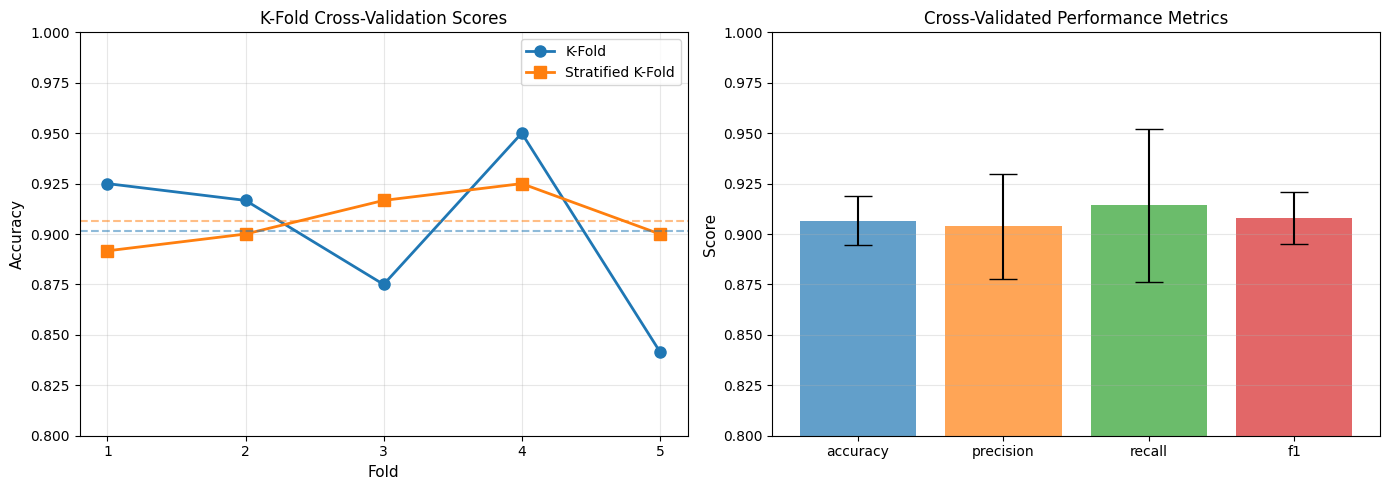

In [6]:
# K-Fold Cross-Validation
from sklearn.model_selection import KFold, cross_val_score

knn = KNeighborsClassifier(n_neighbors=5)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validation scores for each fold
cv_scores = cross_val_score(knn, X_train, y_train, cv=kfold, scoring='accuracy')

print("K-Fold Cross-Validation (K=5):")
print(f"Scores per fold: {cv_scores}")
print(f"Mean CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Stratified K-Fold for imbalanced datasets
skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_stratified = cross_val_score(knn, X_train, y_train, cv=skfold, scoring='accuracy')

print("\nStratified K-Fold Cross-Validation (K=5):")
print(f"Scores per fold: {cv_scores_stratified}")
print(f"Mean CV Score: {cv_scores_stratified.mean():.4f} (+/- {cv_scores_stratified.std():.4f})")

# Cross-validate with multiple metrics
scoring = {'accuracy': 'accuracy', 'precision': 'precision', 'recall': 'recall', 'f1': 'f1'}
cv_results = cross_validate(knn, X_train, y_train, cv=skfold, scoring=scoring, return_train_score=True)

print("\nDetailed Cross-Validation Results:")
print(f"Train Accuracy:  {cv_results['train_accuracy'].mean():.4f}")
print(f"Val Accuracy:    {cv_results['test_accuracy'].mean():.4f}")
print(f"Val Precision:   {cv_results['test_precision'].mean():.4f}")
print(f"Val Recall:      {cv_results['test_recall'].mean():.4f}")
print(f"Val F1:          {cv_results['test_f1'].mean():.4f}")

# Visualize cross-validation results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: K-Fold vs Stratified K-Fold
fold_indices = np.arange(1, 6)
axes[0].plot(fold_indices, cv_scores, 'o-', linewidth=2, markersize=8, label='K-Fold')
axes[0].plot(fold_indices, cv_scores_stratified, 's-', linewidth=2, markersize=8, label='Stratified K-Fold')
axes[0].axhline(cv_scores.mean(), color='C0', linestyle='--', alpha=0.5)
axes[0].axhline(cv_scores_stratified.mean(), color='C1', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Fold', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].set_title('K-Fold Cross-Validation Scores', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(fold_indices)
axes[0].set_ylim([0.8, 1.0])

# Plot 2: Multiple metrics
metrics = ['accuracy', 'precision', 'recall', 'f1']
means = [cv_results['test_accuracy'].mean(), cv_results['test_precision'].mean(), 
         cv_results['test_recall'].mean(), cv_results['test_f1'].mean()]
stds = [cv_results['test_accuracy'].std(), cv_results['test_precision'].std(), 
        cv_results['test_recall'].std(), cv_results['test_f1'].std()]

axes[1].bar(metrics, means, yerr=stds, capsize=10, alpha=0.7, color=['C0', 'C1', 'C2', 'C3'])
axes[1].set_ylabel('Score', fontsize=11)
axes[1].set_title('Cross-Validated Performance Metrics', fontsize=12)
axes[1].set_ylim([0.8, 1.0])
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

---

## Part 4: K-Nearest Neighbors (KNN)

### 4.1 KNN Theory

**Algorithm:**
1. For a new sample, find the K nearest training samples (using distance metric)
2. Predict based on majority vote (classification) or average (regression)

**Advantages:**
- Simple and intuitive
- No training phase (lazy learner)
- Works for multi-class classification

**Disadvantages:**
- Slow prediction (needs to compute distances to all training samples)
- Sensitive to irrelevant features
- Requires feature scaling

KNN Classification Results (K=3):
Accuracy: 0.9333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]

Optimal K: 5 (CV Score: 0.9667)


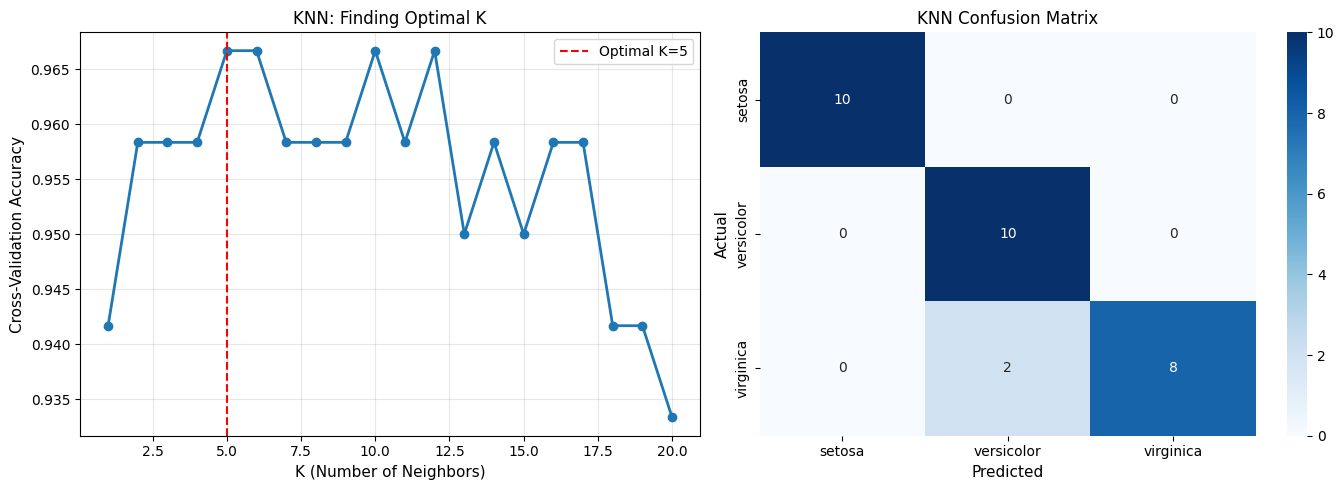

In [7]:
### 4.2 KNN Implementation

# Load Iris dataset for multiclass classification
iris = load_iris()
X_iris, y_iris = iris.data, iris.target

# Split data
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)

# Feature scaling (important for distance-based methods)
scaler = StandardScaler()
X_train_iris_scaled = scaler.fit_transform(X_train_iris)
X_test_iris_scaled = scaler.transform(X_test_iris)

# Train KNN classifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_iris_scaled, y_train_iris)

# Predict on test set
y_pred = knn.predict(X_test_iris_scaled)
y_pred_proba = knn.predict_proba(X_test_iris_scaled)

# Evaluation
accuracy = accuracy_score(y_test_iris, y_pred)
print("KNN Classification Results (K=3):")
print(f"Accuracy: {accuracy:.4f}")
print(f"\nClassification Report:\n{classification_report(y_test_iris, y_pred, target_names=iris.target_names)}")

# Confusion matrix
cm = confusion_matrix(y_test_iris, y_pred)
print("Confusion Matrix:")
print(cm)

# Find optimal K using cross-validation
k_range = range(1, 21)
cv_scores_by_k = []

for k in k_range:
    knn_cv = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_cv, X_train_iris_scaled, y_train_iris, cv=5, scoring='accuracy')
    cv_scores_by_k.append(scores.mean())

optimal_k = k_range[np.argmax(cv_scores_by_k)]
print(f"\nOptimal K: {optimal_k} (CV Score: {max(cv_scores_by_k):.4f})")

# Visualize KNN results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: CV scores for different K values
axes[0].plot(k_range, cv_scores_by_k, 'o-', linewidth=2, markersize=6)
axes[0].axvline(optimal_k, color='red', linestyle='--', label=f'Optimal K={optimal_k}')
axes[0].set_xlabel('K (Number of Neighbors)', fontsize=11)
axes[0].set_ylabel('Cross-Validation Accuracy', fontsize=11)
axes[0].set_title('KNN: Finding Optimal K', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Confusion matrix heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], 
            xticklabels=iris.target_names, yticklabels=iris.target_names)
axes[1].set_xlabel('Predicted', fontsize=11)
axes[1].set_ylabel('Actual', fontsize=11)
axes[1].set_title('KNN Confusion Matrix', fontsize=12)

plt.tight_layout()
plt.show()

---

## Part 5: Support Vector Machine (SVM)

### 5.1 SVM Theory

**Goal:** Find the optimal hyperplane that maximizes the margin between classes

**Key Concepts:**
- **Support Vectors**: Data points closest to the decision boundary
- **Margin**: Distance between the hyperplane and nearest data points
- **Kernel Trick**: Transform data to higher dimensions to handle non-linear patterns
- **C Parameter**: Controls regularization (balance between margin and misclassification)

**Kernels:**
- **Linear**: Good for linearly separable data
- **RBF**: Good for non-linear patterns (default)
- **Polynomial**: Captures polynomial relationships

Breast Cancer Dataset:
Training set: 455 samples
Test set: 114 samples
Features: 30

--- SVM Results with Different Kernels ---
linear  : Train=0.9868, Test=0.9561, F1=0.9645
rbf     : Train=0.9890, Test=0.9825, F1=0.9861
poly    : Train=0.9143, Test=0.8684, F1=0.9045

Detailed Results (RBF Kernel):
Support Vectors: 104 / 455
Accuracy: 0.9825
Precision: 0.9726
Recall: 1.0000
F1-Score: 0.9861

--- Tuning C Parameter (RBF Kernel) ---
C=   0.1: CV Accuracy=0.9451 (+/- 0.0197)
C=   1.0: CV Accuracy=0.9758 (+/- 0.0128)
C=  10.0: CV Accuracy=0.9736 (+/- 0.0149)
C= 100.0: CV Accuracy=0.9604 (+/- 0.0149)

Optimal C: 1


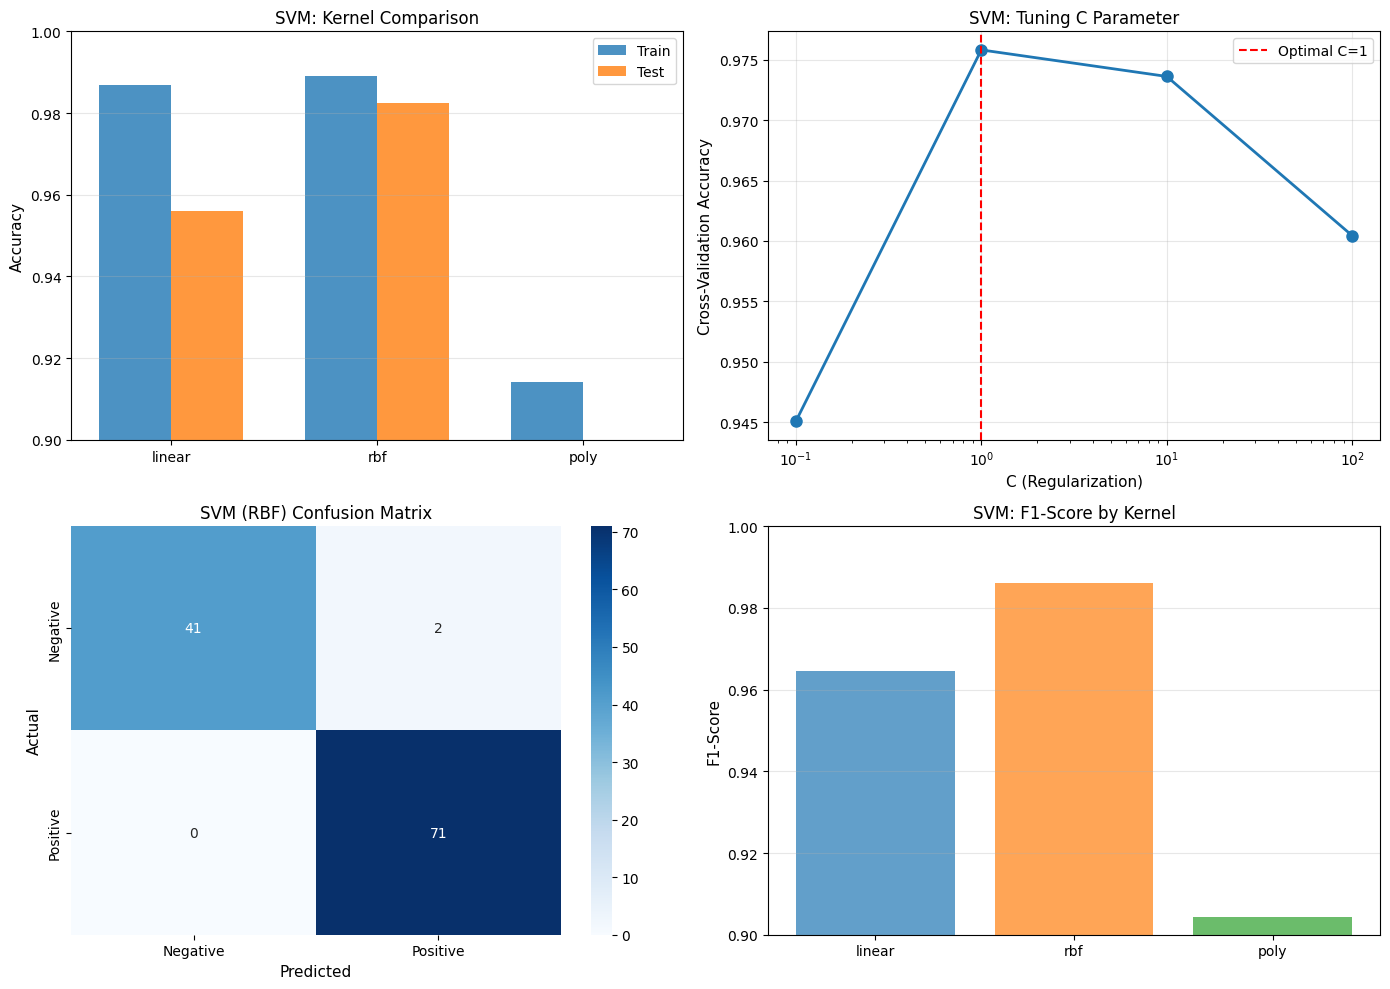

In [8]:
### 5.2 SVM Implementation

# Use breast cancer dataset (binary classification)
cancer = load_breast_cancer()
X_cancer, y_cancer = cancer.data, cancer.target

# Split data
X_train_cancer, X_test_cancer, y_train_cancer, y_test_cancer = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=42
)

# Scaling is CRUCIAL for SVM
scaler_cancer = StandardScaler()
X_train_cancer_scaled = scaler_cancer.fit_transform(X_train_cancer)
X_test_cancer_scaled = scaler_cancer.transform(X_test_cancer)

print("Breast Cancer Dataset:")
print(f"Training set: {X_train_cancer_scaled.shape[0]} samples")
print(f"Test set: {X_test_cancer_scaled.shape[0]} samples")
print(f"Features: {X_train_cancer_scaled.shape[1]}")

# Train SVM with different kernels
kernels = ['linear', 'rbf', 'poly']
results = {}

print("\n--- SVM Results with Different Kernels ---")

for kernel in kernels:
    if kernel == 'poly':
        svm = SVC(kernel=kernel, degree=3, C=1.0, random_state=42)
    else:
        svm = SVC(kernel=kernel, C=1.0, random_state=42)
    
    svm.fit(X_train_cancer_scaled, y_train_cancer)
    train_score = svm.score(X_train_cancer_scaled, y_train_cancer)
    test_score = svm.score(X_test_cancer_scaled, y_test_cancer)
    
    y_pred_svm = svm.predict(X_test_cancer_scaled)
    f1 = f1_score(y_test_cancer, y_pred_svm)
    
    results[kernel] = {'train': train_score, 'test': test_score, 'f1': f1, 'model': svm}
    print(f"{kernel:8s}: Train={train_score:.4f}, Test={test_score:.4f}, F1={f1:.4f}")

# Analyze best model (RBF)
best_model = results['rbf']['model']
y_pred_best = best_model.predict(X_test_cancer_scaled)

print("\nDetailed Results (RBF Kernel):")
print(f"Support Vectors: {len(best_model.support_vectors_)} / {len(X_train_cancer_scaled)}")
print(f"Accuracy: {results['rbf']['test']:.4f}")
print(f"Precision: {precision_score(y_test_cancer, y_pred_best):.4f}")
print(f"Recall: {recall_score(y_test_cancer, y_pred_best):.4f}")
print(f"F1-Score: {results['rbf']['f1']:.4f}")

# Tune C parameter with cross-validation
C_values = [0.1, 1, 10, 100]
cv_scores_svm = []

print("\n--- Tuning C Parameter (RBF Kernel) ---")
for C in C_values:
    svm_cv = SVC(kernel='rbf', C=C, random_state=42)
    scores = cross_val_score(svm_cv, X_train_cancer_scaled, y_train_cancer, cv=5, scoring='accuracy')
    mean_score = scores.mean()
    cv_scores_svm.append(mean_score)
    print(f"C={C:6.1f}: CV Accuracy={mean_score:.4f} (+/- {scores.std():.4f})")

optimal_C = C_values[np.argmax(cv_scores_svm)]
print(f"\nOptimal C: {optimal_C}")

# Visualize SVM results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Kernel comparison
kernel_names = list(results.keys())
train_scores = [results[k]['train'] for k in kernel_names]
test_scores = [results[k]['test'] for k in kernel_names]

x = np.arange(len(kernel_names))
width = 0.35
axes[0, 0].bar(x - width/2, train_scores, width, label='Train', alpha=0.8)
axes[0, 0].bar(x + width/2, test_scores, width, label='Test', alpha=0.8)
axes[0, 0].set_ylabel('Accuracy', fontsize=11)
axes[0, 0].set_title('SVM: Kernel Comparison', fontsize=12)
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(kernel_names)
axes[0, 0].legend()
axes[0, 0].set_ylim([0.9, 1.0])
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Plot 2: C parameter tuning
axes[0, 1].plot(C_values, cv_scores_svm, 'o-', linewidth=2, markersize=8)
axes[0, 1].axvline(optimal_C, color='red', linestyle='--', label=f'Optimal C={optimal_C}')
axes[0, 1].set_xlabel('C (Regularization)', fontsize=11)
axes[0, 1].set_ylabel('Cross-Validation Accuracy', fontsize=11)
axes[0, 1].set_title('SVM: Tuning C Parameter', fontsize=12)
axes[0, 1].set_xscale('log')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Confusion matrix for best model
cm_svm = confusion_matrix(y_test_cancer, y_pred_best)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0],
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
axes[1, 0].set_xlabel('Predicted', fontsize=11)
axes[1, 0].set_ylabel('Actual', fontsize=11)
axes[1, 0].set_title('SVM (RBF) Confusion Matrix', fontsize=12)

# Plot 4: F1-Scores comparison
f1_scores_comparison = [results[k]['f1'] for k in kernel_names]
axes[1, 1].bar(kernel_names, f1_scores_comparison, alpha=0.7, color=['C0', 'C1', 'C2'])
axes[1, 1].set_ylabel('F1-Score', fontsize=11)
axes[1, 1].set_title('SVM: F1-Score by Kernel', fontsize=12)
axes[1, 1].set_ylim([0.9, 1.0])
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

---

## Part 6: KNN vs SVM Comparison

IRIS DATASET (Multiclass Classification)

KNN (K=5):
  Accuracy: 0.9333
  F1-Score (weighted): 0.9327

SVM (RBF):
  Accuracy: 0.9667
  F1-Score (weighted): 0.9666

CANCER DATASET (Binary Classification)

KNN (K=5):
  Accuracy: 0.9474
  F1-Score: 0.9577

SVM (RBF):
  Accuracy: 0.9825
  F1-Score: 0.9861

COMPARISON TABLE
Algorithm  Iris Accuracy  Iris F1  Cancer Accuracy  Cancer F1
      KNN       0.933333 0.932660         0.947368   0.957746
      SVM       0.966667 0.966583         0.982456   0.986111


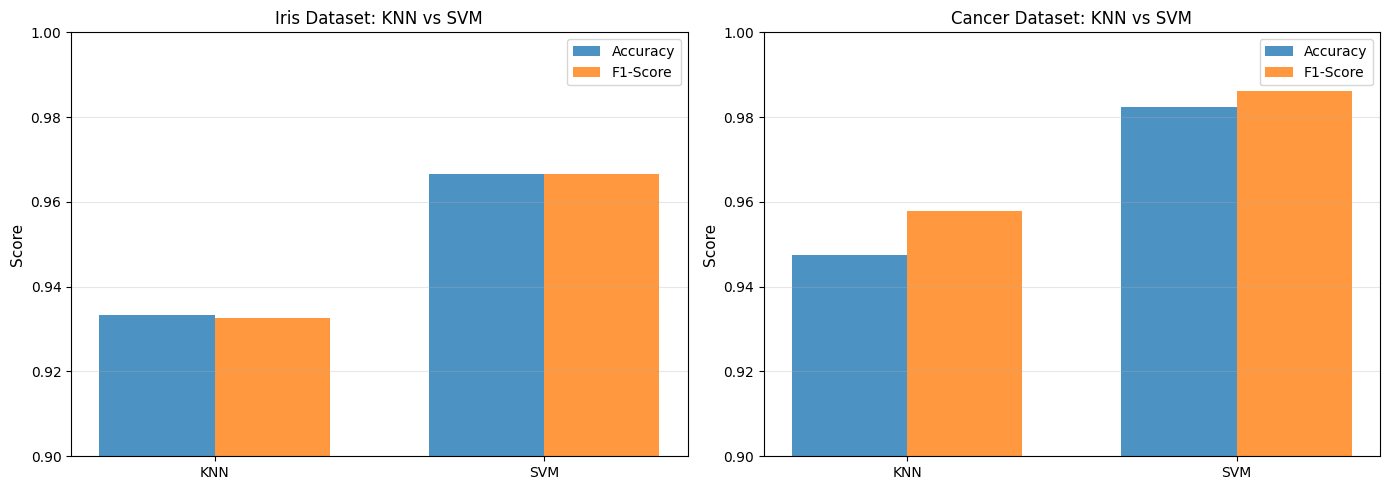

In [9]:
# Compare KNN and SVM on Iris dataset (multiclass)
print("=" * 60)
print("IRIS DATASET (Multiclass Classification)")
print("=" * 60)

# Best KNN model
knn_best = KNeighborsClassifier(n_neighbors=optimal_k)
knn_best.fit(X_train_iris_scaled, y_train_iris)
y_pred_knn_iris = knn_best.predict(X_test_iris_scaled)

knn_iris_acc = accuracy_score(y_test_iris, y_pred_knn_iris)
knn_iris_f1 = f1_score(y_test_iris, y_pred_knn_iris, average='weighted')

print(f"\nKNN (K={optimal_k}):")
print(f"  Accuracy: {knn_iris_acc:.4f}")
print(f"  F1-Score (weighted): {knn_iris_f1:.4f}")

# Best SVM model on Iris
svm_iris = SVC(kernel='rbf', C=1.0, random_state=42)
svm_iris.fit(X_train_iris_scaled, y_train_iris)
y_pred_svm_iris = svm_iris.predict(X_test_iris_scaled)

svm_iris_acc = accuracy_score(y_test_iris, y_pred_svm_iris)
svm_iris_f1 = f1_score(y_test_iris, y_pred_svm_iris, average='weighted')

print(f"\nSVM (RBF):")
print(f"  Accuracy: {svm_iris_acc:.4f}")
print(f"  F1-Score (weighted): {svm_iris_f1:.4f}")

# Compare on Cancer dataset (binary)
print("\n" + "=" * 60)
print("CANCER DATASET (Binary Classification)")
print("=" * 60)

# Best KNN on Cancer
knn_cancer = KNeighborsClassifier(n_neighbors=5)
knn_cancer.fit(X_train_cancer_scaled, y_train_cancer)
y_pred_knn_cancer = knn_cancer.predict(X_test_cancer_scaled)

knn_cancer_acc = knn_cancer.score(X_test_cancer_scaled, y_test_cancer)
knn_cancer_f1 = f1_score(y_test_cancer, y_pred_knn_cancer)

print(f"\nKNN (K=5):")
print(f"  Accuracy: {knn_cancer_acc:.4f}")
print(f"  F1-Score: {knn_cancer_f1:.4f}")

# Best SVM on Cancer (already trained)
svm_cancer_acc = results['rbf']['test']
svm_cancer_f1 = results['rbf']['f1']

print(f"\nSVM (RBF):")
print(f"  Accuracy: {svm_cancer_acc:.4f}")
print(f"  F1-Score: {svm_cancer_f1:.4f}")

# Comprehensive comparison table
comparison_data = {
    'Algorithm': ['KNN', 'SVM'],
    'Iris Accuracy': [knn_iris_acc, svm_iris_acc],
    'Iris F1': [knn_iris_f1, svm_iris_f1],
    'Cancer Accuracy': [knn_cancer_acc, svm_cancer_acc],
    'Cancer F1': [knn_cancer_f1, svm_cancer_f1]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "=" * 60)
print("COMPARISON TABLE")
print("=" * 60)
print(comparison_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Iris dataset comparison
models = ['KNN', 'SVM']
iris_acc = [knn_iris_acc, svm_iris_acc]
iris_f1 = [knn_iris_f1, svm_iris_f1]

x = np.arange(len(models))
width = 0.35
axes[0].bar(x - width/2, iris_acc, width, label='Accuracy', alpha=0.8)
axes[0].bar(x + width/2, iris_f1, width, label='F1-Score', alpha=0.8)
axes[0].set_ylabel('Score', fontsize=11)
axes[0].set_title('Iris Dataset: KNN vs SVM', fontsize=12)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].legend()
axes[0].set_ylim([0.9, 1.0])
axes[0].grid(True, alpha=0.3, axis='y')

# Plot 2: Cancer dataset comparison
cancer_acc = [knn_cancer_acc, svm_cancer_acc]
cancer_f1 = [knn_cancer_f1, svm_cancer_f1]

axes[1].bar(x - width/2, cancer_acc, width, label='Accuracy', alpha=0.8)
axes[1].bar(x + width/2, cancer_f1, width, label='F1-Score', alpha=0.8)
axes[1].set_ylabel('Score', fontsize=11)
axes[1].set_title('Cancer Dataset: KNN vs SVM', fontsize=12)
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].legend()
axes[1].set_ylim([0.9, 1.0])
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

---

## Summary

### Key Concepts Covered:

**1. Data Splitting:**
- Train/Validation/Test split (60/20/20 or 70/15/15)
- Prevents data leakage and enables proper evaluation

**2. Overfitting & Underfitting:**
- Overfitting: Model memorizes training data, poor generalization
- Underfitting: Model too simple, poor performance everywhere
- Solution: Find the sweet spot through hyperparameter tuning

**3. Bias-Variance Tradeoff:**
- Bias: Systematic error (underfitting)
- Variance: Sensitivity to training data (overfitting)
- Total Error = Bias² + Variance + Irreducible Error
- Goal: Minimize bias while controlling variance

**4. Cross-Validation:**
- K-Fold: Divide data into K folds, train K models
- Stratified K-Fold: Maintains class distribution
- More robust than single train/test split
- Provides confidence intervals for performance estimates

**5. K-Nearest Neighbors (KNN):**
- Lazy learner: No explicit training
- Predicts based on K nearest neighbors (majority vote)
- Sensitive to feature scaling
- Hyperparameter: K (optimal found via CV)
- Good for small datasets, multi-class problems

**6. Support Vector Machine (SVM):**
- Finds optimal separating hyperplane
- Maximizes margin between classes
- Kernel trick handles non-linear data
- Hyperparameters: C (regularization), kernel type, γ (for RBF)
- Scalable, works well with high-dimensional data

### When to Use:

| Problem | KNN | SVM |
|---------|-----|-----|
| Small dataset | ✓ | ✓ |
| High dimensions | ✗ | ✓ |
| Speed important | ✗ | ✓ |
| Interpretability | ✓ | ✗ |
| Many classes | ✓ | ~ |
| Non-linear | ✓ | ✓ |